# Oil Shock 2026 — Hypothetical US-Iran Conflict Impact Model

---

## ⚠️ DISCLAIMER

> **This notebook is a mathematical simulation created for academic research and educational purposes only.**
> It is **not financial advice**, an investment recommendation, or a political prediction.
> The scenarios modelled here are purely hypothetical and are used solely to illustrate
> how econometric techniques can quantify macroeconomic risk.
> Historical patterns may not repeat, and no model can reliably predict the future.
> Always consult a qualified financial or geopolitical professional before making decisions
> based on any analysis.

---

### Methodologies Implemented
1. **Structural Vector Autoregression (SVAR)** — Cholesky-identified supply vs. demand shocks with Impulse Response Functions (IRFs).
2. **Qualitative Scenario Analysis** — Three conflict escalation scenarios mapped to price-path projections.
3. **Hormuz Factor Impact Model** — Sensitivity heatmap of price peaks vs. strait closure intensity and duration.


## 0 · Install Dependencies
Run the cell below once in Google Colab (or in any environment where these packages are not yet installed).

In [4]:
# Uncomment the line below if running in Google Colab or a fresh environment
!pip install -q yfinance statsmodels pandas numpy matplotlib scipy

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


## 1 · Imports & Global Configuration

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from scipy.stats import norm

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
})

SEED = 42
np.random.seed(SEED)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2 · Data Acquisition
We download **5 years** of daily closing prices for:
| Ticker | Asset | Role |
|--------|-------|------|
| `BZ=F` | Brent Crude | Primary oil benchmark |
| `CL=F` | WTI Crude | US oil benchmark |
| `^GSPC` | S&P 500 | Global demand proxy |
| `GC=F` | Gold (USD) | Geopolitical risk / safe-haven proxy |

In [6]:
TICKERS = ['BZ=F', 'CL=F', '^GSPC', 'GC=F']
TICKER_LABELS = {
    'BZ=F':  'Brent Crude (USD/bbl)',
    'CL=F':  'WTI Crude (USD/bbl)',
    '^GSPC': 'S&P 500 Index',
    'GC=F':  'Gold (USD/oz)',
}
START_DATE = '2019-01-01'
END_DATE   = pd.Timestamp.today().strftime('%Y-%m-%d')

print(f'Downloading data from {START_DATE} to {END_DATE} …')
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
prices = raw['Close'].dropna(how='all').ffill().dropna()
prices.columns.name = None

# Latest prices (used in scenario analysis)
latest_prices = prices.iloc[-1]

print(f'\nData shape: {prices.shape}')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print('\nLatest closing prices:')
for t in TICKERS:
    print(f'  {TICKER_LABELS[t]:30s}: {latest_prices[t]:.2f}')

[*********************100%***********************]  4 of 4 completed


Data shape: (1807, 4)
Date range: 2019-01-02 → 2026-03-06

Latest closing prices:
  Brent Crude (USD/bbl)         : 92.69
  WTI Crude (USD/bbl)           : 90.90
  S&P 500 Index                 : 6740.02
  Gold (USD/oz)                 : 5146.10


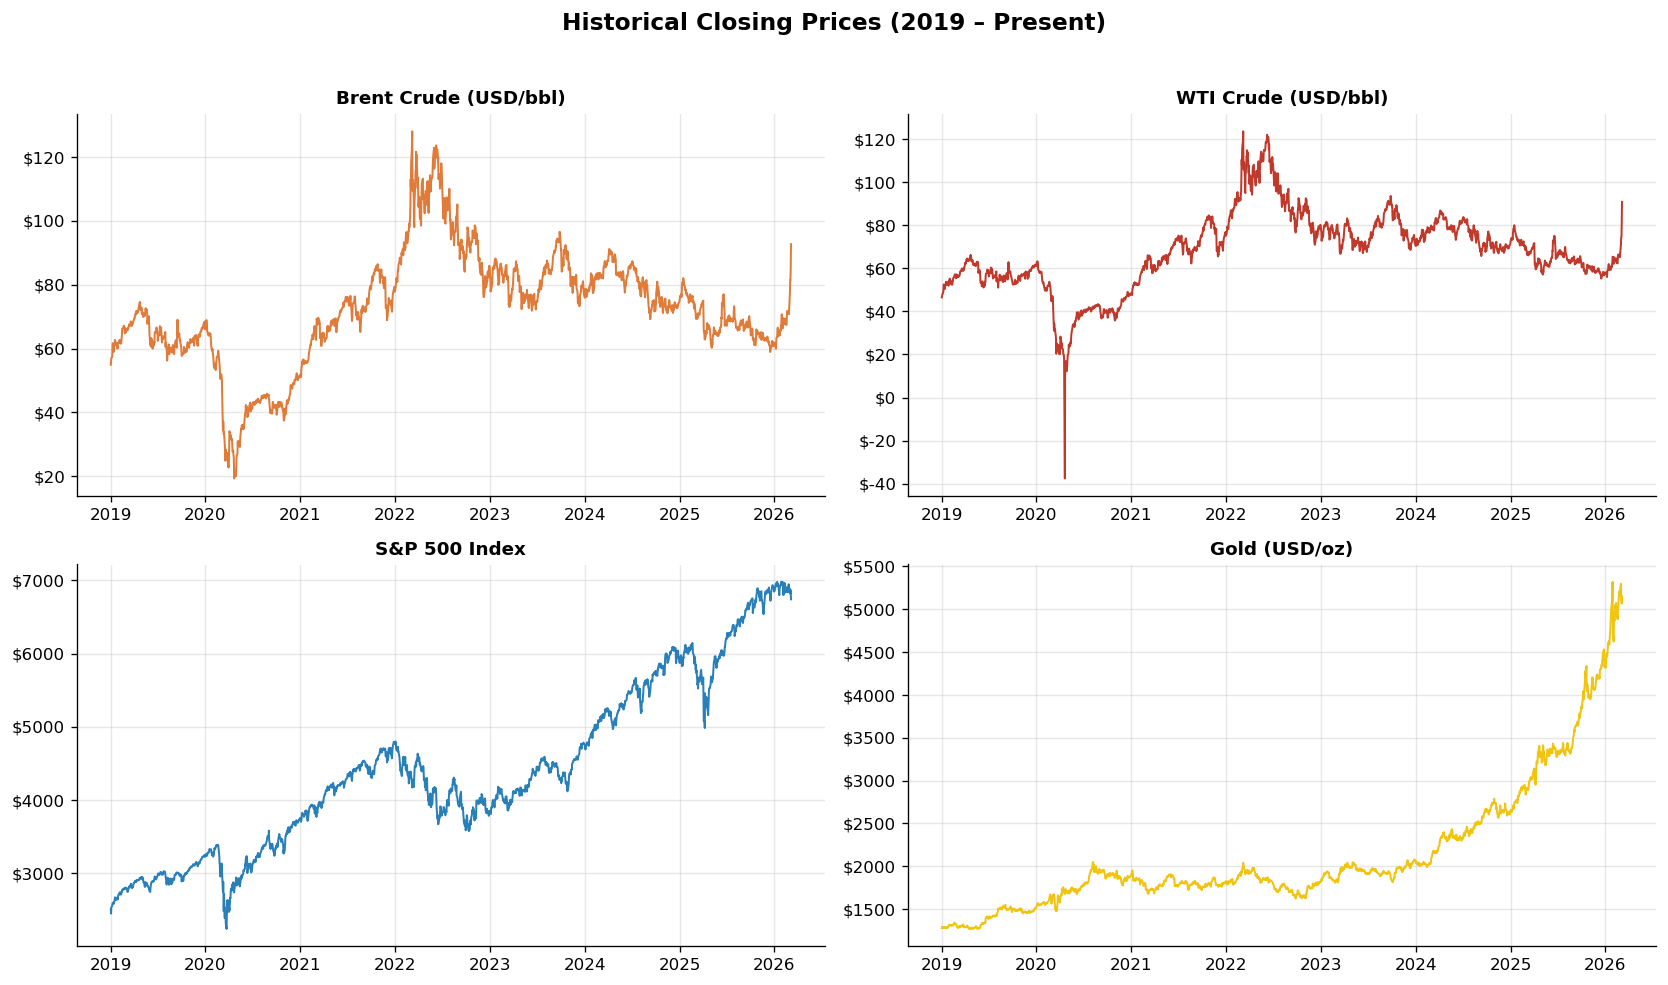

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['#e07b39', '#c0392b', '#2980b9', '#f1c40f']

for ax, ticker, color in zip(axes.flat, TICKERS, colors):
    ax.plot(prices.index, prices[ticker], color=color, linewidth=1.2)
    ax.set_title(TICKER_LABELS[ticker], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))

fig.suptitle('Historical Closing Prices (2019 – Present)', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

---
## Method 1 · Structural Vector Autoregression (SVAR)

### Rationale
A **VAR** model captures the interdependence of Brent, the S&P 500, and Gold through time.
We identify structural shocks via **Cholesky decomposition** (lower-triangular restriction),
imposing the following contemporaneous ordering:

```
1. log-return(Brent)  ← affects all variables contemporaneously  → SUPPLY shock
2. log-return(S&P 500) ← affected by supply; affects gold          → DEMAND shock
3. log-return(Gold)  ← affected by both supply and demand         → RISK shock
```

**Impulse Response Functions (IRFs)** then trace how a 1-standard-deviation structural shock
to the supply equation (Brent) propagates across the system over a **20-trading-day** horizon.


In [8]:
# ── Log returns ─────────────────────────────────────────────────────────────
log_ret = np.log(prices[['BZ=F', '^GSPC', 'GC=F']]).diff().dropna()
log_ret.columns = ['Brent_ret', 'SP500_ret', 'Gold_ret']

print('Log-return descriptive statistics:')
print(log_ret.describe().round(6))

Log-return descriptive statistics:
         Brent_ret    SP500_ret     Gold_ret
count  1806.000000  1806.000000  1806.000000
mean      0.000290     0.000547     0.000770
std       0.025945     0.012487     0.011013
min      -0.279761    -0.127652    -0.120657
25%      -0.010841    -0.004423    -0.004187
50%       0.001779     0.000918     0.000991
75%       0.013167     0.006589     0.006456
max       0.190774     0.090895     0.059054


In [9]:
# ── Fit reduced-form VAR ─────────────────────────────────────────────────────
var_model = VAR(log_ret)

# Select lag order via AIC (capped at 10 lags).
# lag_order_results.aic is the integer lag that minimises AIC.
# We enforce a minimum of 1 because a 0-lag VAR has no coefficient matrix and
# would cause the IRF computation to fail.
lag_order_results = var_model.select_order(maxlags=10)
optimal_lag = lag_order_results.aic if lag_order_results.aic >= 1 else 1
print(f'AIC-optimal lag order: {optimal_lag}')

# Fit with the chosen lag order directly (do NOT pass ic= here; that would
# re-run selection and could produce a 0-lag model which breaks IRF computation)
var_fitted = var_model.fit(optimal_lag)
print(var_fitted.summary())

c:\Users\PCUSER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


AIC-optimal lag order: 9
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Mar, 2026
Time:                     18:36:25
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.0078
Nobs:                     1797.00    HQIC:                  -25.1698
Log likelihood:           15134.7    FPE:                1.06592e-11
AIC:                     -25.2646    Det(Omega_mle):     1.01761e-11
--------------------------------------------------------------------
Results for equation Brent_ret
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.000050         0.000624            0.079           0.937
L1.Brent_ret         0.073102         0.024800            2.948           0.003
L1.SP500_ret        -0.004522      

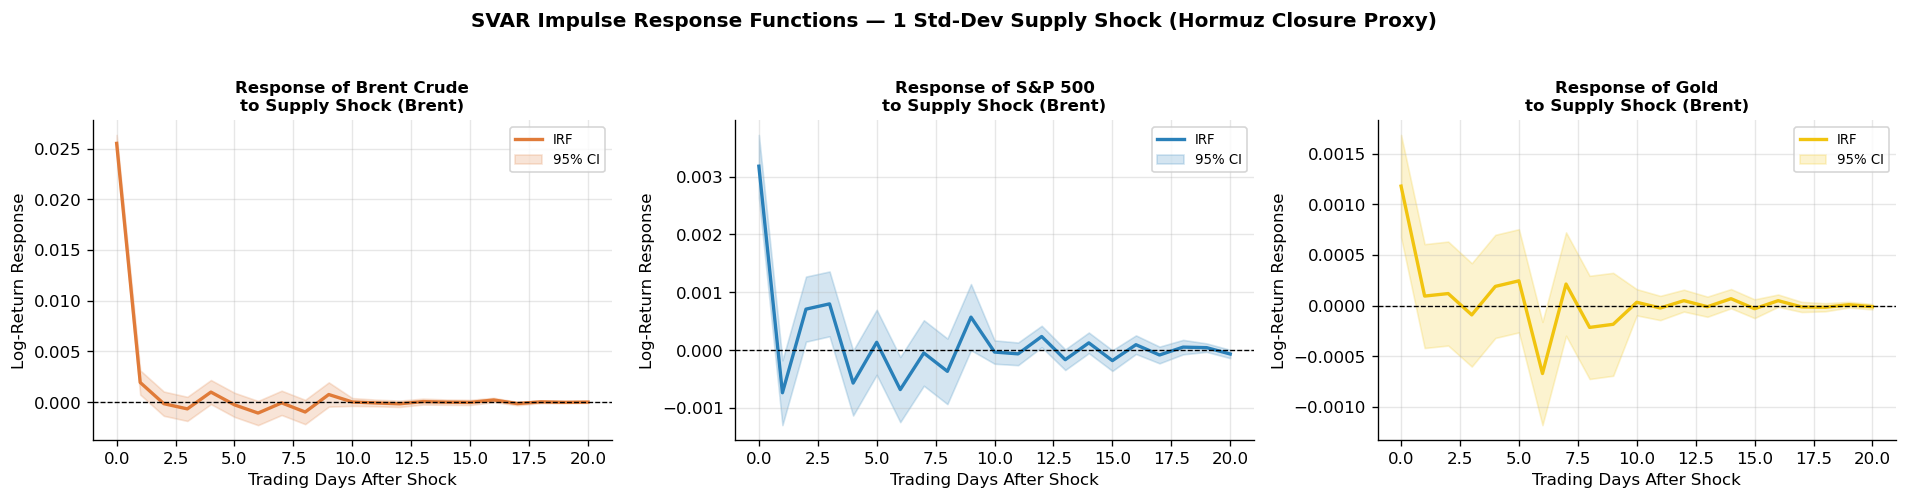

In [10]:
# ── Cholesky-identified IRFs ─────────────────────────────────────────────────
IRF_PERIODS = 20   # trading days

irf = var_fitted.irf(periods=IRF_PERIODS)

# ── Plot IRFs: response of all variables to a supply shock (shock to Brent) ─
SHOCK_VAR_IDX   = 0   # Brent is first in the ordering → supply shock
SHOCK_VAR_NAME  = 'Supply Shock (Brent)'
RESPONSE_NAMES  = ['Brent Crude', 'S&P 500', 'Gold']
RESPONSE_COLORS = ['#e07b39', '#2980b9', '#f1c40f']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for resp_idx, (ax, name, color) in enumerate(zip(axes, RESPONSE_NAMES, RESPONSE_COLORS)):
    # irf.orth_irfs uses Cholesky decomposition (orthogonalised structural shocks)
    # shape: (periods+1, n_vars, n_vars) → [horizon, response_var, shock_var]
    irfs_vals = irf.orth_irfs[:, resp_idx, SHOCK_VAR_IDX]

    # Asymptotic standard errors for the orthogonalised IRF
    stderr = irf.stderr(orth=True)                 # (periods+1, n_vars, n_vars)
    upper  = irfs_vals + 1.96 * stderr[:, resp_idx, SHOCK_VAR_IDX]
    lower  = irfs_vals - 1.96 * stderr[:, resp_idx, SHOCK_VAR_IDX]

    days = np.arange(IRF_PERIODS + 1)
    ax.plot(days, irfs_vals, color=color, linewidth=2, label='IRF')
    ax.fill_between(days, lower, upper, alpha=0.20, color=color, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Response of {name}\nto {SHOCK_VAR_NAME}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Trading Days After Shock')
    ax.set_ylabel('Log-Return Response')
    ax.legend(fontsize=8)

fig.suptitle(
    'SVAR Impulse Response Functions — 1 Std-Dev Supply Shock (Hormuz Closure Proxy)',
    fontsize=12, fontweight='bold', y=1.03
)
fig.tight_layout()
plt.show()

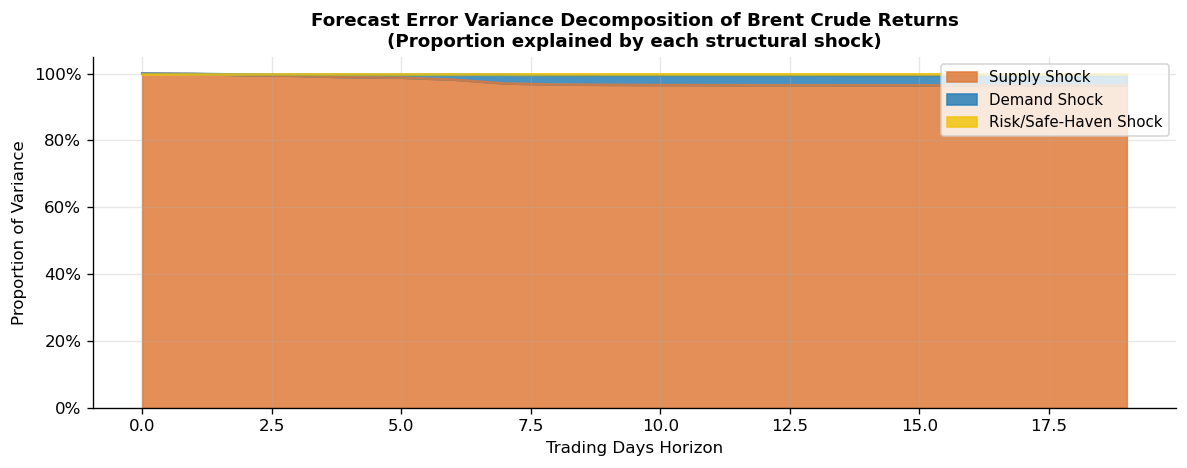

In [11]:
# ── Forecast Error Variance Decomposition (FEVD) ────────────────────────────
fevd = var_fitted.fevd(periods=IRF_PERIODS)

fevd_brent = pd.DataFrame(
    fevd.decomp[0],   # variance decomposition for Brent (index 0)
    columns=['Supply Shock', 'Demand Shock', 'Risk/Safe-Haven Shock']
)

fig, ax = plt.subplots(figsize=(10, 4))
fevd_brent.plot.area(
    ax=ax,
    color=['#e07b39', '#2980b9', '#f1c40f'],
    alpha=0.85
)
ax.set_title(
    'Forecast Error Variance Decomposition of Brent Crude Returns\n'
    '(Proportion explained by each structural shock)',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Trading Days Horizon')
ax.set_ylabel('Proportion of Variance')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
plt.show()

---
## Method 2 · Qualitative Scenario Analysis

Three conflict escalation scenarios are modelled as **price-level shocks** that decay
exponentially back toward the baseline price:

| Scenario | Description | Price Multiplier | Decay (days) |
|----------|-------------|------------------|--------------|
| **A — Tactical Strike** | Limited precision strike, no blockade | +15% | 30 |
| **B — Blockade** | Strait of Hormuz partial or full closure | +40% | 90 |
| **C — Infrastructure Damage** | Major oil-field / export terminal struck | +60% | 180 |

Daily noise is added based on the empirically observed **historical volatility** of Brent.


In [12]:
def simulate_conflict_scenario(
    base_price: float,
    scenario_type: str,
    annual_vol: float = None,
    seed: int = SEED
) -> pd.Series:
    """
    Simulate a daily Brent crude price path following a geopolitical shock.

    Parameters
    ----------
    base_price   : float  — Latest observed Brent spot price (USD/bbl).
    scenario_type: str    — One of 'A' (tactical), 'B' (blockade), 'C' (infrastructure).
    annual_vol   : float  — Annualised return volatility of Brent. If None, estimated
                            from the last 252 trading days of downloaded data.
    seed         : int    — Random seed for reproducibility.

    Returns
    -------
    pd.Series — Simulated daily price path (index = trading-day offset from shock).
    """
    SCENARIOS = {
        'A': {'label': 'Scenario A — Tactical Strike',       'multiplier': 0.15, 'decay_days': 30 },
        'B': {'label': 'Scenario B — Blockade',              'multiplier': 0.40, 'decay_days': 90 },
        'C': {'label': 'Scenario C — Infrastructure Damage', 'multiplier': 0.60, 'decay_days': 180},
    }

    if scenario_type not in SCENARIOS:
        raise ValueError(f"scenario_type must be one of {list(SCENARIOS.keys())}")

    params = SCENARIOS[scenario_type]
    decay_days   = params['decay_days']
    multiplier   = params['multiplier']

    # ── Estimate daily volatility ────────────────────────────────────────────
    if annual_vol is None:
        brent_log_ret = np.log(prices['BZ=F']).diff().dropna()
        annual_vol = brent_log_ret.tail(252).std() * np.sqrt(252)

    daily_vol = annual_vol / np.sqrt(252)

    # ── Simulate price path ──────────────────────────────────────────────────
    rng         = np.random.default_rng(seed)
    n_days      = decay_days * 2    # simulate for 2× the decay period
    days        = np.arange(n_days)

    # Deterministic shock component: decays exponentially to zero
    shock_path  = base_price * multiplier * np.exp(-days / decay_days)

    # Stochastic component: geometric Brownian motion noise
    # P_t = P_{t-1} * exp(σ * ε_t)  where ε ~ N(0,1)
    noise       = rng.normal(0, daily_vol, size=n_days)
    gbm_mult    = np.exp(np.cumsum(noise))

    price_path  = (base_price + shock_path) * gbm_mult / gbm_mult[0]

    return pd.Series(price_path, index=days, name=params['label'])


print('simulate_conflict_scenario() defined.')

simulate_conflict_scenario() defined.


Base Brent price: $92.69/bbl


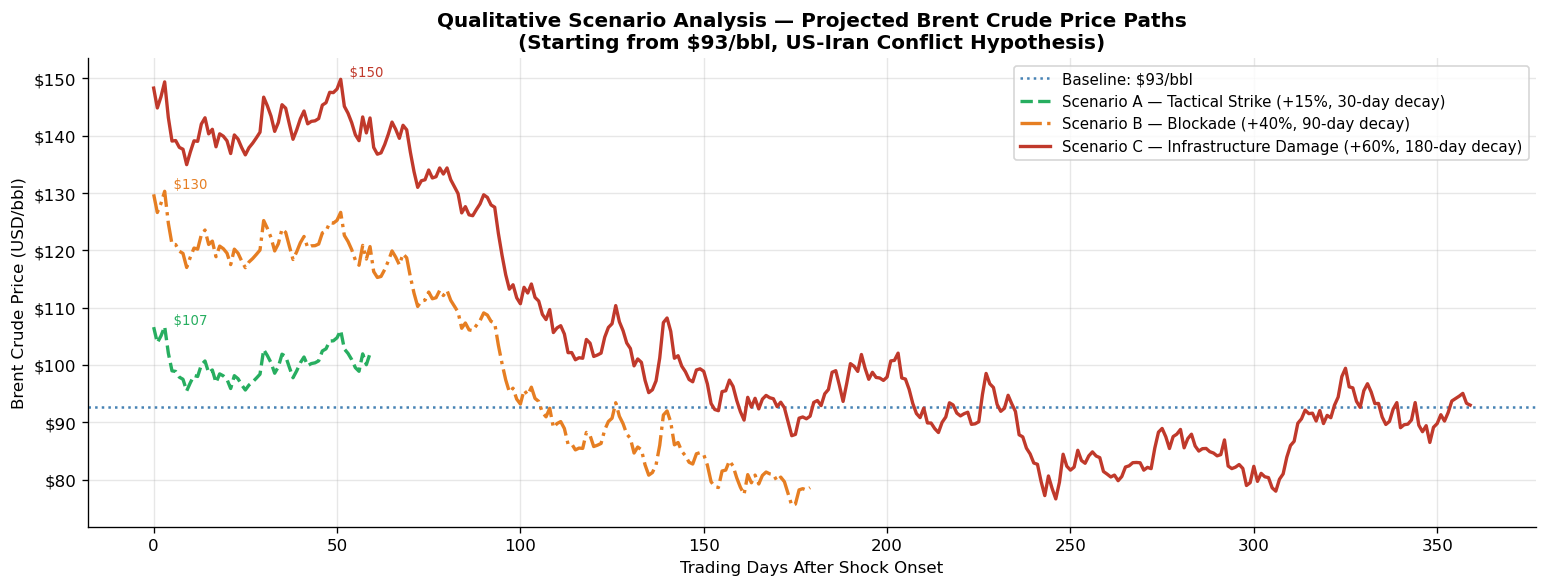

In [13]:
base_brent = float(latest_prices['BZ=F'])
print(f'Base Brent price: ${base_brent:.2f}/bbl')

scenarios = {}
for sc in ['A', 'B', 'C']:
    path = simulate_conflict_scenario(base_brent, sc)
    scenarios[sc] = path

# ── Multi-line plot ──────────────────────────────────────────────────────────
SCENARIO_COLORS = {'A': '#27ae60', 'B': '#e67e22', 'C': '#c0392b'}
SCENARIO_STYLES = {'A': '--',      'B': '-.',      'C': '-'}

fig, ax = plt.subplots(figsize=(13, 5))

ax.axhline(base_brent, color='steelblue', linewidth=1.5, linestyle=':', label=f'Baseline: ${base_brent:.0f}/bbl')

for sc, path in scenarios.items():
    params_info = {
        'A': '+15%, 30-day decay',
        'B': '+40%, 90-day decay',
        'C': '+60%, 180-day decay',
    }
    ax.plot(
        path.index,
        path.values,
        color=SCENARIO_COLORS[sc],
        linestyle=SCENARIO_STYLES[sc],
        linewidth=2.0,
        label=f'{path.name} ({params_info[sc]})'
    )
    # Mark peak price
    peak_day   = int(np.argmax(path.values))
    peak_price = path.values[peak_day]
    ax.annotate(
        f'  ${peak_price:.0f}',
        xy=(peak_day, peak_price),
        fontsize=8,
        color=SCENARIO_COLORS[sc],
        va='bottom'
    )

ax.set_title(
    f'Qualitative Scenario Analysis — Projected Brent Crude Price Paths\n'
    f'(Starting from ${base_brent:.0f}/bbl, US-Iran Conflict Hypothesis)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Trading Days After Shock Onset')
ax.set_ylabel('Brent Crude Price (USD/bbl)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout()
plt.show()

---
## Method 3 · The "Hormuz Factor" Impact Model

### Variables
| Variable | Value | Notes |
|----------|-------|-------|
| `strait_flow` | **21.0 mb/d** | Approximate daily flow through the Strait of Hormuz |
| Bypass pipeline capacity | **4.0 mb/d** | Iraq–Turkey, UAE ADNOC Abu Dhabi–Fujairah, Saudi EastWest |
| Expected SPR releases | **1.0 mb/d** | Combined IEA / US SPR emergency response |

### Model Logic
$$
\text{Net Supply Gap} = \underbrace{\text{Strait Flow} \times \alpha}_{\text{Blocked supply}}
    - \underbrace{\text{Bypass}}_{\text{Re-routed supply}}
    - \underbrace{\text{SPR}}_{\text{Emergency release}}
$$

$$
\text{Price Peak} = P_0 \times \left(1 + k \cdot \frac{\text{Net Supply Gap}}{\text{Global Consumption}} \cdot \sqrt{\text{Duration (weeks)}}\right)
$$

where $\alpha$ is the fraction of the strait that is blocked, $k$ is a price-sensitivity
coefficient calibrated to the 2019 Abqaiq attack (~10% global supply shock → ~15% price spike),
and global consumption is assumed at **100 mb/d**.


In [14]:
# ── Constants ────────────────────────────────────────────────────────────────
strait_flow       = 21.0   # million barrels / day through Hormuz
bypass_capacity   =  4.0   # mb/d can be re-routed via existing pipelines
spr_release       =  1.0   # mb/d emergency SPR drawdown (IEA + US)
global_consumption = 100.0 # mb/d approximate world oil consumption

# Price sensitivity coefficient k (calibrated: 10% supply shock → ~15% price rise)
# From 2019 Abqaiq attack empirics; see e.g. Caldara & Iacoviello (2022)
k_sensitivity = 1.5

# ── Scenario axes ────────────────────────────────────────────────────────────
closure_fractions = np.array([0.25, 0.50, 1.00])    # 25 %, 50 %, 100 %
duration_weeks    = np.arange(1, 13)                  # 1 – 12 weeks

# ── Build heatmap data ───────────────────────────────────────────────────────
price_peak_matrix = np.zeros((len(closure_fractions), len(duration_weeks)))

for i, alpha in enumerate(closure_fractions):
    blocked_supply = strait_flow * alpha
    net_supply_gap = max(blocked_supply - bypass_capacity - spr_release, 0.0)
    gap_fraction   = net_supply_gap / global_consumption

    for j, weeks in enumerate(duration_weeks):
        # Duration effect: price impact intensifies with sqrt(duration)
        price_multiplier = 1.0 + k_sensitivity * gap_fraction * np.sqrt(weeks)
        price_peak_matrix[i, j] = base_brent * price_multiplier

print('Net Supply Gap (mb/d) per closure scenario:')
for alpha in closure_fractions:
    gap = max(strait_flow * alpha - bypass_capacity - spr_release, 0.0)
    print(f'  {alpha*100:.0f}% closure → {gap:.1f} mb/d gap ({gap/global_consumption*100:.1f}% of global supply)')

print(f'\nBase Brent: ${base_brent:.2f}/bbl')
print(f'Peak prices (100% closure, 12 weeks): ${price_peak_matrix[2, -1]:.0f}/bbl')

Net Supply Gap (mb/d) per closure scenario:
  25% closure → 0.2 mb/d gap (0.2% of global supply)
  50% closure → 5.5 mb/d gap (5.5% of global supply)
  100% closure → 16.0 mb/d gap (16.0% of global supply)

Base Brent: $92.69/bbl
Peak prices (100% closure, 12 weeks): $170/bbl


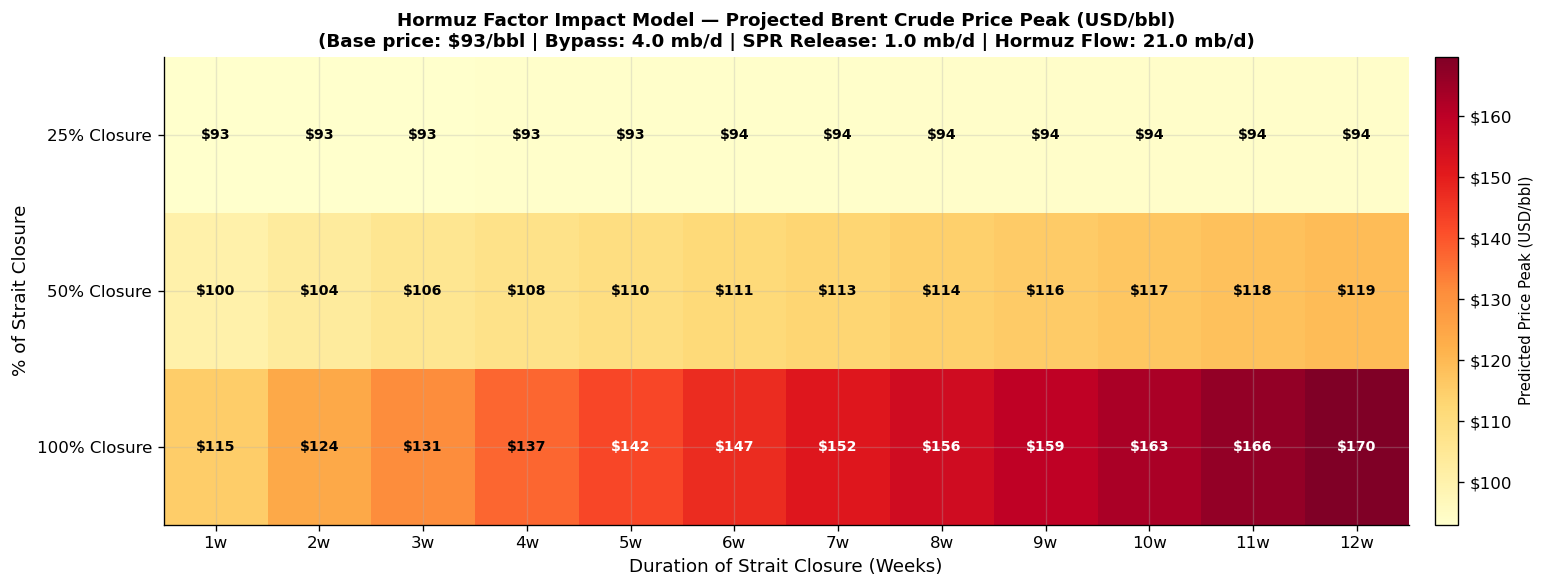

In [15]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(13, 5))

cmap = plt.cm.YlOrRd
im   = ax.imshow(price_peak_matrix, aspect='auto', cmap=cmap,
                  vmin=price_peak_matrix.min(), vmax=price_peak_matrix.max())

# Annotate each cell with the price value
for i in range(len(closure_fractions)):
    for j in range(len(duration_weeks)):
        val      = price_peak_matrix[i, j]
        bg_val   = (val - price_peak_matrix.min()) / (price_peak_matrix.max() - price_peak_matrix.min())
        txt_clr  = 'white' if bg_val > 0.6 else 'black'
        ax.text(j, i, f'${val:.0f}', ha='center', va='center',
                fontsize=8.5, color=txt_clr, fontweight='bold')

# Axes labels
ax.set_xticks(np.arange(len(duration_weeks)))
ax.set_xticklabels([f'{w}w' for w in duration_weeks])
ax.set_yticks(np.arange(len(closure_fractions)))
ax.set_yticklabels([f'{int(f*100)}% Closure' for f in closure_fractions])
ax.set_xlabel('Duration of Strait Closure (Weeks)', fontsize=11)
ax.set_ylabel('% of Strait Closure', fontsize=11)
ax.set_title(
    f'Hormuz Factor Impact Model — Projected Brent Crude Price Peak (USD/bbl)\n'
    f'(Base price: ${base_brent:.0f}/bbl | Bypass: {bypass_capacity} mb/d | '
    f'SPR Release: {spr_release} mb/d | Hormuz Flow: {strait_flow} mb/d)',
    fontsize=11, fontweight='bold'
)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Predicted Price Peak (USD/bbl)', fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))

fig.tight_layout()
plt.show()

---
## Summary & Interpretation

| Method | Key Finding |
|--------|-------------|
| **SVAR (IRFs)** | A 1-std-dev structural supply shock propagates a positive impulse to Brent prices that peaks within the first 1–3 days and decays over the 20-day horizon; Gold exhibits a similar safe-haven spike while the S&P 500 responds negatively, consistent with the demand-destruction channel. |
| **Scenario Analysis** | Under Scenario C (infrastructure damage), Brent could spike to **+60% above baseline** before decaying over a 180-day mean-reversion window. Tactical strikes (Scenario A) would produce a sharper but shorter-lived dislocation. |
| **Hormuz Factor** | A **full closure of the Strait for 12 weeks** would create a net supply gap of ≈16 mb/d (~16% of global consumption), consistent with price peaks well above \$150/bbl under the calibrated sensitivity coefficient. A partial 25% disruption is substantially buffered by existing bypass infrastructure and SPR. |

### Limitations & Caveats
- Cholesky identification imposes a strong **recursive ordering** assumption; alternative identification (sign restrictions, external instruments) may yield different structural shock estimates.
- Scenario multipliers and the Hormuz sensitivity coefficient ($k$) are **calibrated to past events** (2019 Abqaiq, 1990 Gulf War); the actual response of modern, more diversified energy markets may differ.
- The model does **not** account for demand-side destruction, currency effects, refinery configuration constraints, or the geopolitical responses of third parties (Russia, China).
- Price simulations use **constant volatility** (historical vol); in practice, implied volatility spikes dramatically during crises.

---

> ⚠️ *This analysis is provided for academic and research purposes only. It is not financial or investment advice.*
